In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
students = pd.read_csv("../Data/raw/studentInfo.csv")
vle = pd.read_csv("../Data/raw/vle.csv")
student_vle = pd.read_csv("../Data/raw/studentVle.csv")
assessments = pd.read_csv("../Data/raw/assessments.csv")
student_assessments = pd.read_csv("../Data/raw/studentAssessment.csv")
courses = pd.read_csv("../Data/raw/courses.csv")

In [19]:
# Aperçu des datasets
for name, df in {
    "students": students,
    "vle": vle,
    "student_vle": student_vle,
    "assessments": assessments,
    "student_assessments": student_assessments,
    "courses": courses,
}.items():
    print("\n###", name)
    display(df.head())
    print(df.shape)



### students


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


(32593, 12)

### vle


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


(6364, 6)

### student_vle


...

(206, 6)

### student_assessments


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


(173912, 5)

### courses


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


(22, 3)


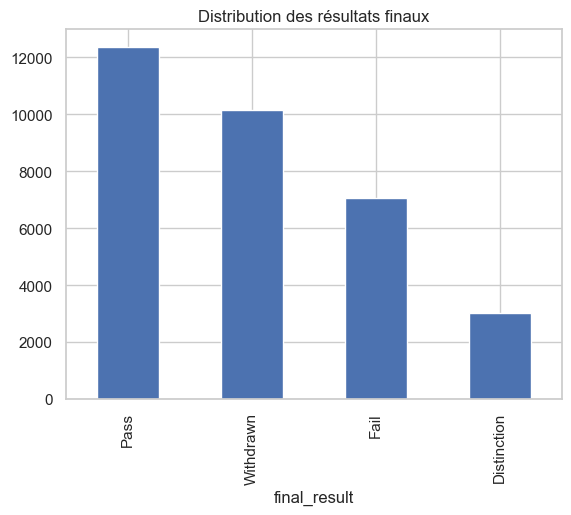

In [20]:
# Indicateurs de base 
students["final_result"].value_counts().plot(kind="bar")
plt.title("Distribution des résultats finaux")
plt.show()

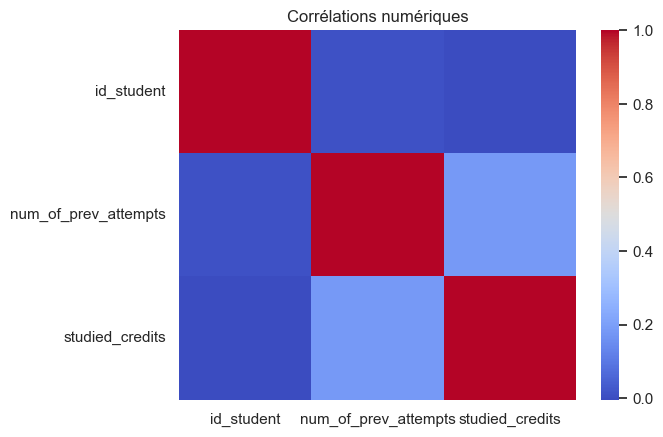

In [6]:
# Corrélations
num_cols = students.select_dtypes(include=[np.number]).corr()
sns.heatmap(num_cols, annot=False, cmap="coolwarm")
plt.title("Corrélations numériques")
plt.show()

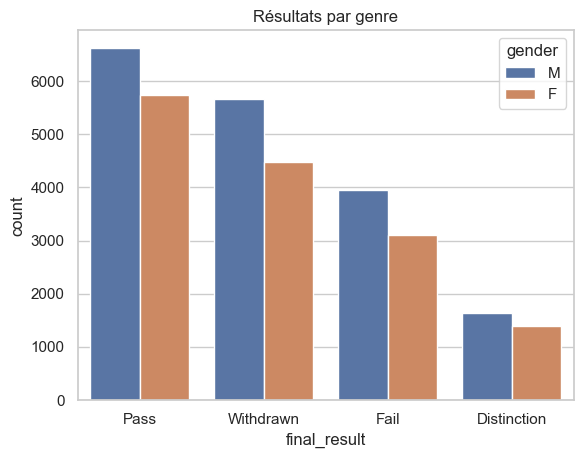

In [8]:
# eda_oulad
# Profil étudiant
sns.countplot(data=students, x="final_result", hue="gender")
plt.title("Résultats par genre")
plt.show()

<Axes: xlabel='final_result', ylabel='age_band'>

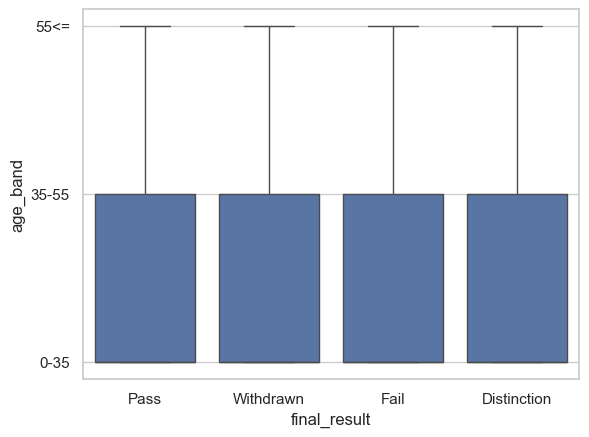

In [9]:
# Âges et abandon
sns.boxplot(data=students, x="final_result", y="age_band")

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'AAA'),
  Text(1, 0, 'BBB'),
  Text(2, 0, 'CCC'),
  Text(3, 0, 'DDD'),
  Text(4, 0, 'EEE'),
  Text(5, 0, 'FFF'),
  Text(6, 0, 'GGG')])

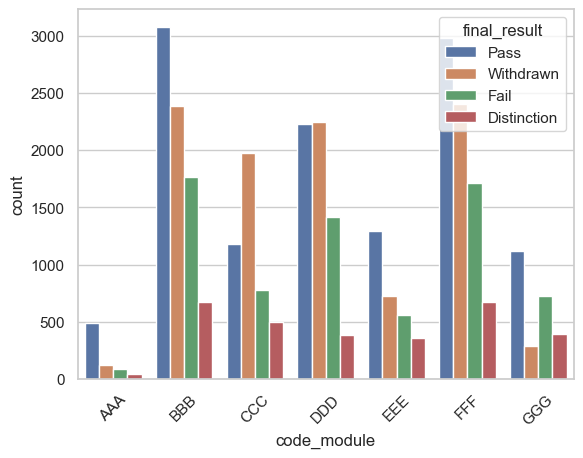

In [10]:
# Par cours
sns.countplot(data=students, x="code_module", hue="final_result")
plt.xticks(rotation=45)

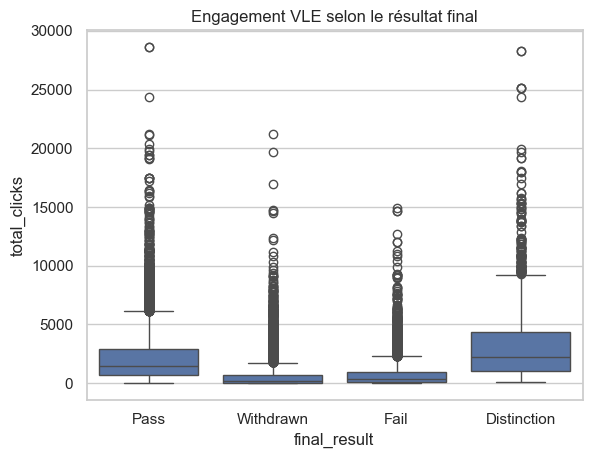

<Axes: xlabel='total_clicks', ylabel='score'>

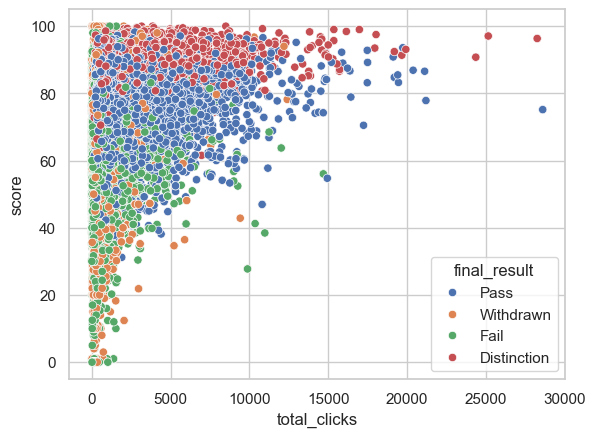

In [21]:
# at_risk_analysis (La clé : engagement VLE + soumissions + résultats antérieurs → risque)
# 1.Calculer un score d’engagement
engagement = student_vle.groupby("id_student")["sum_click"].sum().reset_index()
engagement.columns = ["id_student", "total_clicks"]

# 2.Fusion avec les résultats
df = students.merge(engagement, on="id_student", how="left")
df["total_clicks"] = df["total_clicks"].fillna(0)

# 3.Visualisation
sns.boxplot(data=df, x="final_result", y="total_clicks")
plt.title("Engagement VLE selon le résultat final")
plt.show()

# 4.Détection simple
threshold = df["total_clicks"].quantile(0.25)
df["at_risk"] = df["total_clicks"] < threshold
df["at_risk"].mean()

# 5.Scatter engagement vs score
merged = student_assessments.merge(assessments[["id_assessment","weight"]], on="id_assessment")
merged = merged.groupby("id_student")["score"].mean().reset_index()

tmp = df.merge(merged, on="id_student", how="left")

sns.scatterplot(data=tmp, x="total_clicks", y="score", hue="final_result")

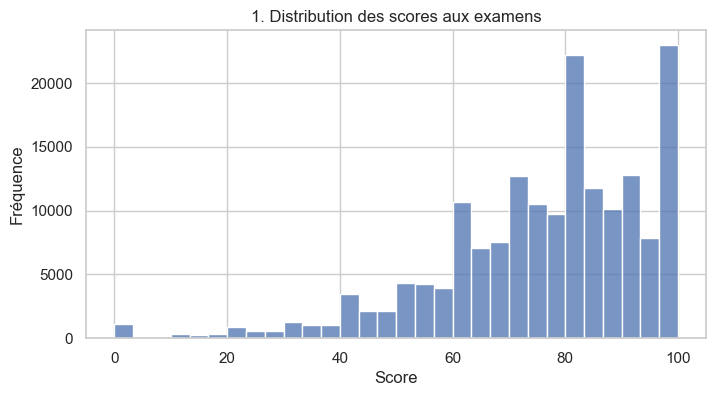

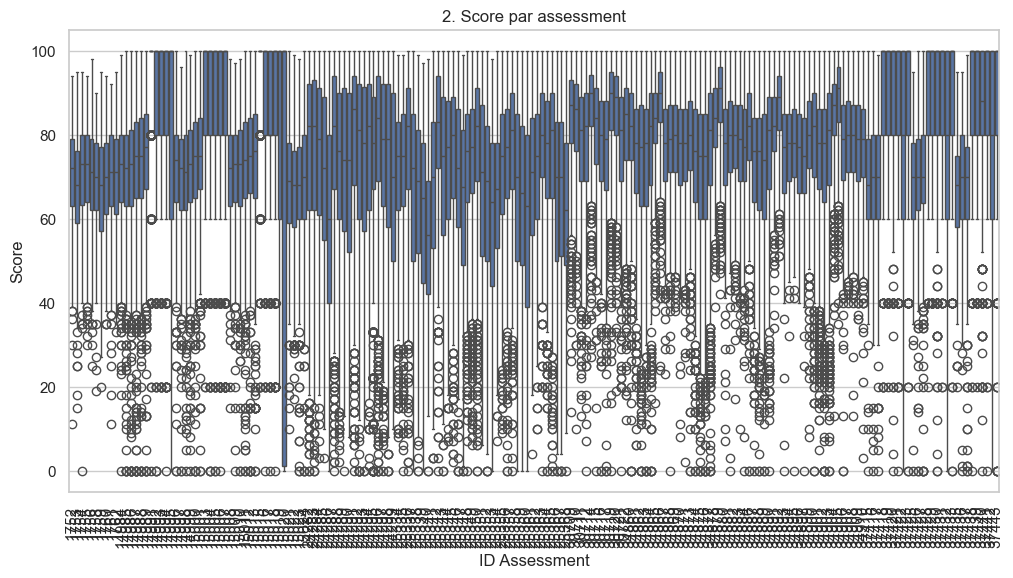

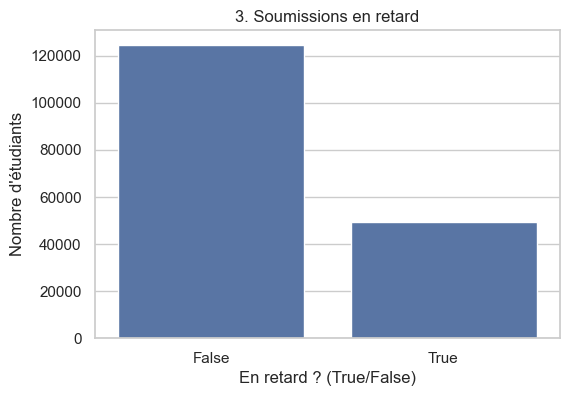

In [22]:
# quiz_patterns
# ============================================================
# 1. Merge pour ajouter la date d'évaluation dans student_assessments
# ============================================================
student_assessments = student_assessments.merge(
    assessments[["id_assessment", "date"]],
    on="id_assessment",
    how="left"
)

# ============================================================
# 2. Distribution des scores
# ============================================================
plt.figure(figsize=(8,4))
sns.histplot(student_assessments["score"], bins=30)
plt.title("1. Distribution des scores aux examens")
plt.xlabel("Score")
plt.ylabel("Fréquence")
plt.show()

# ============================================================
# 3. Score par type d’assessment
# ============================================================
plt.figure(figsize=(12,6))
sns.boxplot(data=student_assessments, x="id_assessment", y="score")
plt.xticks(rotation=90)
plt.title("2. Score par assessment")
plt.xlabel("ID Assessment")
plt.ylabel("Score")
plt.show()

# ============================================================
# 4. Soumissions en retard (Late submissions)
# ============================================================
# Calcul du retard : soumission > date de l'évaluation
student_assessments["late"] = student_assessments["date_submitted"] > student_assessments["date"]

plt.figure(figsize=(6,4))
sns.countplot(data=student_assessments, x="late")
plt.title("3. Soumissions en retard")
plt.xlabel("En retard ? (True/False)")
plt.ylabel("Nombre d'étudiants")
plt.show()

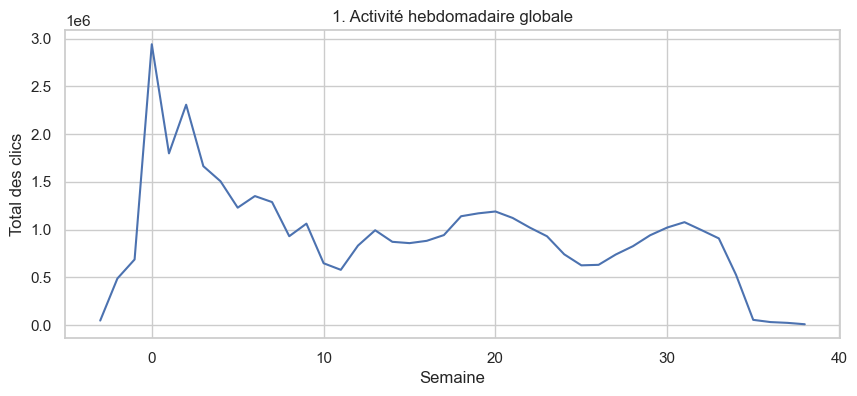

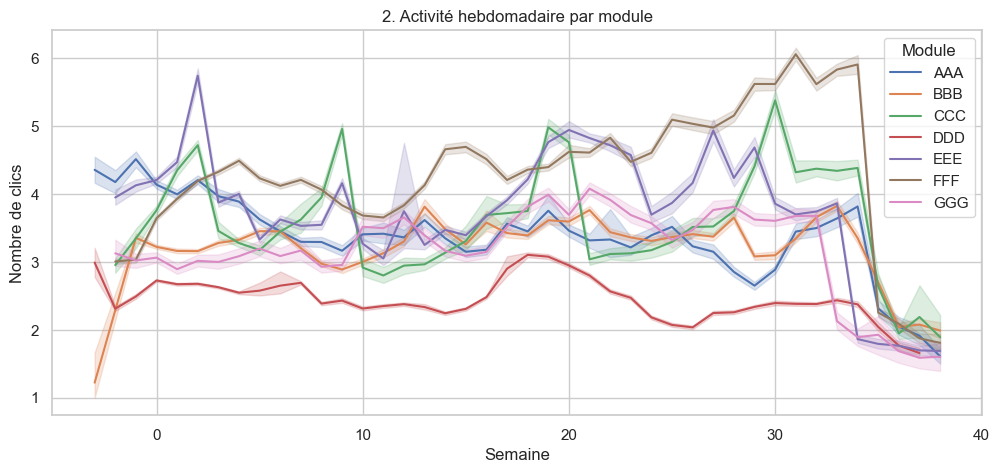

In [24]:
# Engagement_dashboard
# ============================================================
# 1. Créer une colonne "week"
# ============================================================
# Certains cours commencent au jour 0, d'autres au jour -10 → on normalise
student_vle["week"] = (student_vle["date"] / 7).astype(int)

# ============================================================
# 2. Activité globale par semaine
# ============================================================
weekly = student_vle.groupby("week")["sum_click"].sum().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=weekly, x="week", y="sum_click")
plt.title("1. Activité hebdomadaire globale")
plt.xlabel("Semaine")
plt.ylabel("Total des clics")
plt.show()

# ============================================================
# 3. Activité par module (module-wise activity)
# ============================================================
tmp = student_vle.merge(
    courses[["code_module", "code_presentation", "module_presentation_length"]],
    on=["code_module", "code_presentation"],
    how="left"
)

plt.figure(figsize=(12,5))
sns.lineplot(data=tmp, x="week", y="sum_click", hue="code_module")
plt.title("2. Activité hebdomadaire par module")
plt.xlabel("Semaine")
plt.ylabel("Nombre de clics")
plt.legend(title="Module")
plt.show()

<Axes: xlabel='delta', ylabel='Count'>

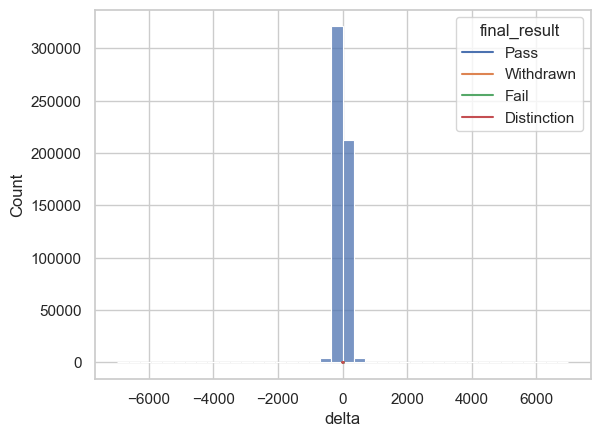

In [26]:
# intervention_insights
# 1. Détection des chutes d'engagement
tmp = student_vle.groupby(["id_student","week"])["sum_click"].sum().reset_index()

tmp["delta"] = tmp.groupby("id_student")["sum_click"].diff()

sns.histplot(tmp["delta"], bins=40)

# 2. Identifier les semaines critiques
critical_weeks = tmp.groupby("week")["delta"].mean().sort_values()
critical_weeks.head()

# 3. Connecter ça au résultat final
df = tmp.merge(students[["id_student","final_result"]])
sns.lineplot(data=df, x="week", y="delta", hue="final_result")